In [29]:
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as un
from astropy.cosmology import Planck15
from matplotlib import colors, rcParams

import py21cmsense as p21sense
from py21cmsense.observatory import Observatory
from py21cmsense.sensitivity import PowerSpectrum
from py21cmsense.theory import EOS2021

rcParams.update({"font.size": 20})

In [30]:

def freq2z(f):
    """Convert frequency in MHz to redshift."""
    return 1420.4 / f - 1.0


def z2freq(z):
    """Convert redshift to frequency in MHz."""
    return 1420.4 / (z + 1.0)


def get_senses(
    observation,
    freq_bands,
    kperp_edges_hmpc,
    kpar_edges_hmpc,
    calc_2d=False,
    foreground_model="moderate",
    theory_model=EOS2021,
    **kwargs,
):
    """Calculate the sensitivity for a set of frequency bands."""
    h = observation.cosmo.H0.value / 100.0
    redshifts = kwargs["redshifts"]
    mock_senses = {}
    mock_senses["kperp_edges_hMpc"] = kperp_edges_hmpc
    mock_senses["kpar_edges_hMpc"] = kpar_edges_hmpc
    mock_senses["redshifts"] = redshifts
    mock_senses["freq_bands"] = freq_bands
    mock_senses["h"] = h

    for _i, band, zval in zip(range(len(freq_bands)), freq_bands, redshifts):
        this_z = {}
        band_name = str(np.round(band, 1)) + " MHz"

        sense = PowerSpectrum(
            observation=observation, foreground_model=foreground_model, theory_model=theory_model()
        ).at_frequency(band * un.MHz)
        if calc_2d:
            sense2d_sample = sense.calculate_sensitivity_2d_grid(
                kperp_edges=kperp_edges_hmpc, kpar_edges=kpar_edges_hmpc, thermal=False, sample=True
            )
            this_z["sample_2D_mK2"] = sense2d_sample.value

            sense2d_thermal = sense.calculate_sensitivity_2d_grid(
                kperp_edges=kperp_edges_hmpc, kpar_edges=kpar_edges_hmpc, thermal=True, sample=False
            )
            this_z["thermal_2D_mK2"] = sense2d_thermal.value

            both = np.sqrt(sense2d_sample.value**2 + sense2d_thermal.value**2)
            this_z["sample_and_thermal_2D_mK2"] = both

        sense1d_sample = sense.calculate_sensitivity_1d(thermal=False, sample=True)
        this_z["sample_1D_mK2"] = sense1d_sample.value
        this_z["theory_1D_mK2"] = sense.theory_model.delta_squared(
            zval, sense.k1d.value * mock_senses["h"]
        ).value

        this_z["k_1D_Mpc"] = sense.k1d.value * mock_senses["h"]
        sense1d_thermal = sense.calculate_sensitivity_1d(thermal=True, sample=False)
        this_z["thermal_1D_mK2"] = sense1d_thermal.value

        sense1d_both = sense.calculate_sensitivity_1d(thermal=True, sample=True)
        this_z["sample_and_thermal_1D_mK2"] = sense1d_both.value
        mock_senses[band_name] = this_z
    return mock_senses



In [31]:

aaast = Observatory.from_ska("AA4")
aa4 = Observatory.from_ska("AA*")



AA* has 512 stations
AA4 has 307 stations


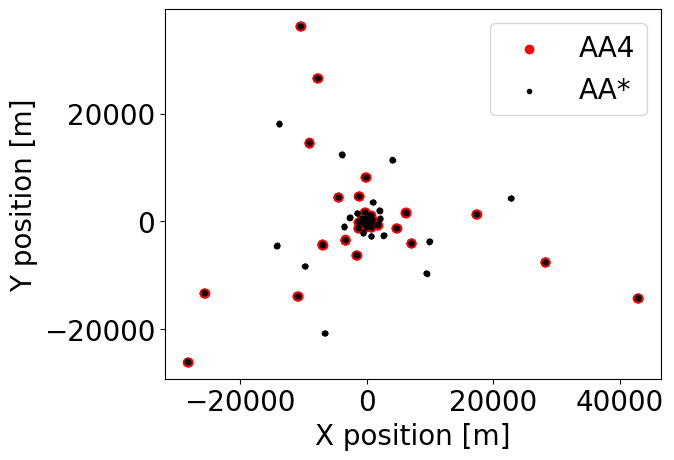

In [32]:
aaast_antpos = aaast.antpos.value[:, :2]  # exclude z position
aa4_antpos = aa4.antpos.value[:, :2]  # exclude z position
print("AA* has", aaast_antpos.shape[0], "stations")
print("AA4 has", aa4_antpos.shape[0], "stations")
plt.scatter(aa4_antpos[:, 0], aa4_antpos[:, 1], label="AA4", color="r")
plt.scatter(aaast_antpos[:, 0], aaast_antpos[:, 1], label="AA*", color="k", marker=".")
plt.legend()
plt.ylabel("Y position [m]")
plt.xlabel("X position [m]")
plt.show()



In [33]:
redshift = 8.01
freq = 1420 / (redshift + 1)
freq_bands = np.array([freq])  # MHz
zs = freq2z(freq_bands)



In [34]:
observation_params = {}
# observation_params["ndays"] = 180.0
observation_params["ndays"] = 18
observation_params["cosmo"] = Planck15
observation_params["h"] = Planck15.H0.value / 100.0
observation_params["freq_bands"] = freq_bands
observation_params["redshifts"] = zs
observation_params["time_per_day_hrs"] = 6.0

In [37]:


# Only needed if we want to calculate the 2D sensitivity
# Set the kperp and kpar bins at which we want to calculate the 2D sensitivity
sense_params = {}
sense_params["calc_2d"] = True
sense_params["foreground_model"] = "moderate"
sense_params["redshifts"] = zs
sense_params["freq_bands"] = freq_bands
sense_params["kperp_edges_hmpc"] = un.Quantity(np.logspace(-1.5, 0.3, 15), "littleh/Mpc")
sense_params["kpar_edges_hmpc"] = un.Quantity(np.logspace(-1.5, 0.3, 15), "littleh/Mpc")
sense_params["kpar_mpc"] = (
    np.exp(
        (
            np.log(sense_params["kpar_edges_hmpc"].value[:-1])
            + np.log(sense_params["kpar_edges_hmpc"].value[1:])
        )
        / 2
    )
    * observation_params["h"]
)
sense_params["kperp_mpc"] = (
    np.exp(
        (
            np.log(sense_params["kperp_edges_hmpc"].value[:-1])
            + np.log(sense_params["kperp_edges_hmpc"].value[1:])
        )
        / 2
    )
    * observation_params["h"]
)



In [38]:
obs = p21sense.Observation(
    observatory=aa4,
    lst_bin_size=observation_params["time_per_day_hrs"] * un.hour,
    time_per_day=observation_params["time_per_day_hrs"] * un.hour,
    n_days=observation_params["ndays"],
    cosmo=observation_params["cosmo"],
    coherent=True,
    # To point to dish off-zenith, use: phase_center_dec=-30.0*un.deg,
    # max baseline is 73km and there are ~260k bls so the gridding takes a very long time.
    # we add a baseline filer to only keep baselines up to 1km.
    baseline_filters=p21sense.BaselineRange(bl_max=1e3 * un.m),
)

In [10]:

# sense_params["foreground_model"] = "optimistic"
# ska_aaast_senses1 = get_senses(
#     obs.clone(observatory=aaast),
#     **sense_params,
# )



In [39]:
sense = PowerSpectrum(
            observation=obs.clone(observatory=aaast)
        )

In [40]:
sense1d = sense.calculate_sensitivity_1d(thermal=True, sample=True)

averaging to 1D: 100%|██████████| 282/282 [00:02<00:00, 115.47kperp-bins/s]


In [41]:
k_values = np.load('/home/leon/Documents/codes/sbi_21cm_ps/data/k_values.npy') # k values in 1/Mpc
k_values = k_values / observation_params["h"]   #  k values in h/Mpc
k_values

array([0.03779433, 0.04300787, 0.04894059, 0.05569169, 0.06337408,
       0.07211622, 0.08206428, 0.09338464, 0.10626657, 0.12092551,
       0.13760657, 0.1565887 , 0.17818932, 0.20276964, 0.23074069,
       0.2625702 , 0.29879043, 0.34000706, 0.38690931, 0.4402815 ,
       0.5010161 , 0.57012874, 0.64877512, 0.73827037, 0.84011103,
       0.9560001 , 1.08787548, 1.2379424 , 1.4087103 , 1.60303476,
       1.8241653 , 2.07579968])

In [42]:
sense.k1d

<Quantity [0.06738094, 0.13476189, 0.20214283, 0.26952378, 0.33690472,
           0.40428566, 0.47166661, 0.53904755, 0.60642849, 0.67380944,
           0.74119038, 0.80857133, 0.87595227, 0.94333321, 1.01071416,
           1.0780951 , 1.14547605, 1.21285699, 1.28023793, 1.34761888,
           1.41499982, 1.48238076, 1.54976171, 1.61714265, 1.6845236 ,
           1.75190454, 1.81928548, 1.88666643, 1.95404737, 2.02142832,
           2.08880926, 2.1561902 , 2.22357115, 2.29095209, 2.35833303,
           2.42571398, 2.49309492, 2.56047587, 2.62785681, 2.69523775,
           2.7626187 , 2.82999964, 2.89738059, 2.96476153, 3.03214247,
           3.09952342, 3.16690436, 3.2342853 , 3.30166625, 3.36904719,
           3.43642814, 3.50380908, 3.57119002, 3.63857097, 3.70595191,
           3.77333286, 3.8407138 , 3.90809474, 3.97547569, 4.04285663,
           4.11023757, 4.17761852, 4.24499946, 4.31238041, 4.37976135,
           4.44714229, 4.51452324, 4.58190418, 4.64928513, 4.71666607,
      

In [43]:
from scipy.interpolate import interp1d
# sigma_f_x = interp1d(sense.k1d.value, sense1d.value, kind='linear', fill_value='extrapolate')

In [44]:
# sigma_k_values = sigma_f_x(k_values)

In [47]:
sigma_k_values

array([         nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,   1.40938738,   1.5532608 ,   1.71698084,
         1.99221222,   2.33278759,   2.76695612,   3.2898326 ,
         3.98365041,   4.98337969,   6.4043163 ,   8.31071791,
        11.07676062,  15.01347626,  20.81786744,  29.23169641,
        41.6017057 ,  60.29969801,  87.86452726, 129.00962784])

In [48]:
import numpy as np
from scipy.interpolate import interp1d

x_src = sense.k1d.value
y_src = sense1d.value

valid_mask = ~np.isnan(x_src) & ~np.isnan(y_src)

x_clean = x_src[valid_mask]
y_clean = y_src[valid_mask]

sigma_f_x = interp1d(x_clean, y_clean, kind='linear', fill_value='extrapolate')

sigma_k_values = sigma_f_x(k_values)

In [49]:
sigma_k_values
sigma_k_values[np.where(np.isnan(sigma_k_values))[0]] = 1.01163727

In [ ]:
# np.save("data/sigma_pk_z8.01_108_hours.npy", sigma_k_values)